# AI for Chemistry — Week 05, Session A
## Deep learning I: tensors, MLPs and backpropagation

**Course:** AI for Chemistry · **Session:** 05A (interleaved lecture + lab,
2.5 h) · **Runtime:** < 10 s, no GPU.

### Suggested timing (solo study, ~120 min)

| Section | Topic | Time |
|--------:|-------|-----:|
| 0 | Setup | 5 min |
| 1 | Tensors, shapes, broadcasting | 22 min |
| 2 | Dense layers and why non-linearity is required | 22 min |
| 3 | Backpropagation: chain rule vs `autograd` | 22 min |
| 4 | Building an MLP; one manual training step | 20 min |
| 5 | Exercises (4) | 29 min |

### Learning objectives
1. State a tensor's rank and shape, and use broadcasting to combine tensors of
   different shapes without writing an explicit loop. *(LO5)*
2. Explain, with the algebra, why stacking linear layers needs a non-linear
   activation between them; name and plot ReLU, sigmoid, tanh. *(LO5)*
3. Compute a gradient by hand for a simple loss and confirm it against
   PyTorch's `autograd`. *(LO5)*
4. Define an MLP as an `nn.Module` and run one forward/backward/optimiser
   step by hand. *(LO5)*

### Prerequisites — before this notebook you should be able to
- Week 03: standardisation, MSE loss, train/test splitting.
- Week 01B: NumPy arrays and vectorised operations.
- *No prior PyTorch experience is assumed.*

### How to use this notebook (solo study)
Read, run, check each **✅** cell in order. This notebook is deliberately
**mechanics-only** — no full training run happens until Week 05B. This is the
**solutions** notebook.


---
## 0. Setup

Load the ESOL descriptor block exactly as in Week 03 (rebuilding
`esol_clean.csv` if needed) and hold out the **same** 80/20 test split
(`random_state=42`) that Week 03 used, so later weeks can compare fairly. We
fix both NumPy's and PyTorch's random seeds — PyTorch has its **own**
generator, seeding NumPy alone is not enough.

**What to look for:** `Xtr` is a `torch.FloatTensor` of shape `(893, 7)` (the
80% train+val pool; Week 05B splits it further into train/val).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
RDLogger.DisableLog("rdApp.*")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 0xC0FFEE
np.random.seed(SEED)
torch.manual_seed(SEED)          # PyTorch keeps its own RNG state

ROOT = Path.cwd()
while not (ROOT / "sources").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "sources" / "datasets"
FIGDIR = ROOT / "lectures" / "week-05_deep-learning-i" / "slides" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

TARGET = "measured log solubility in mols per litre"
DESCRIPTORS = {
    "MolWt": Descriptors.MolWt, "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA, "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
}

def canonical_or_none(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol) if mol is not None else None

clean_path = DATA / "esol_clean.csv"
if clean_path.is_file():
    esol = pd.read_csv(clean_path)
else:
    raw = pd.read_csv(DATA / "esol_delaney.csv")
    raw.columns = raw.columns.str.strip()
    raw["canonical_smiles"] = raw["smiles"].apply(canonical_or_none)
    raw = raw[raw["canonical_smiles"].notna() & raw[TARGET].notna()]
    esol = raw.drop_duplicates("canonical_smiles").reset_index(drop=True)
    esol = esol[esol[TARGET].between(-13, 2)].reset_index(drop=True)
    esol.to_csv(clean_path, index=False)

mols = [Chem.MolFromSmiles(s) for s in esol["canonical_smiles"]]
desc_names = list(DESCRIPTORS)
Xdesc = np.array([[fn(m) for fn in DESCRIPTORS.values()] for m in mols], dtype=float)
y = esol[TARGET].to_numpy()

X_trainval, X_test, y_trainval, y_test = train_test_split(
    Xdesc, y, test_size=0.2, random_state=42)          # same split as Week 03

scaler = StandardScaler().fit(X_trainval)
Xtr = torch.tensor(scaler.transform(X_trainval), dtype=torch.float32)
ytr = torch.tensor(y_trainval, dtype=torch.float32).unsqueeze(-1)

print("Xtr:", Xtr.shape, Xtr.dtype, "  ytr:", ytr.shape)


Xtr: torch.Size([893, 7]) torch.float32   ytr: torch.Size([893, 1])


> **Common errors — Setup**
> - Forgetting `torch.manual_seed(...)` and expecting `np.random.seed(...)`
>   alone to make PyTorch results reproducible — it will not; PyTorch draws
>   from its own generator.
> - `dtype` mismatches: `torch.tensor(numpy_float64_array)` silently becomes a
>   `DoubleTensor` unless you pass `dtype=torch.float32` — mixing float32 and
>   float64 tensors raises a `RuntimeError` at the first matrix multiply.


---
## 1. Tensors, shapes and broadcasting

A **tensor**'s **rank** is how many indices it takes to name one element; its
**shape** is the size along each axis. A batch of molecules, each with 7
descriptors, is naturally a **rank-2** tensor of shape `(N, 7)` — by
convention in deep learning, **axis 0 is always the batch axis**.

**Broadcasting** lets you combine tensors of different shapes without writing
a loop: shapes are compared from the *last* axis backwards, and any axis of
size 1 is stretched to match. Standardising a feature block —
$x_{ij} \to (x_{ij}-\bar x_j)/s_j$ — is exactly this: a `(N, 7)` tensor minus a
`(7,)` tensor of per-feature means.

**What to look for:** `Xtr.mean(dim=0)` has shape `(7,)`; after standardising,
every column's mean is ~0 and standard deviation is ~1.


In [2]:
print("Xtr rank:", Xtr.dim(), " shape:", tuple(Xtr.shape))

col_mean = Xtr.mean(dim=0)          # shape (7,)  -- one mean per descriptor
col_std = Xtr.std(dim=0)            # shape (7,)
print("col_mean shape:", tuple(col_mean.shape))

Xtr_std = (Xtr - col_mean) / col_std     # (893,7) - (7,) broadcasts over axis 0
print("after standardising -> mean:", Xtr_std.mean(dim=0).abs().max().item(),
      " std:", Xtr_std.std(dim=0).sub(1).abs().max().item())


Xtr rank: 2  shape: (893, 7)
col_mean shape: (7,)
after standardising -> mean: 2.269381838004847e-08  std: 5.960464477539063e-08


A chemistry-flavoured broadcasting example: build the **pairwise absolute
difference in logP** between every pair of training molecules — a rank-2
matrix from a rank-1 vector, using exactly the trick from dmol.pub's tensor
chapter (insert a new axis with `None`/`unsqueeze`, then subtract).

**What to look for:** `logp_diff` has shape `(893, 893)`; its diagonal is all
zero (every molecule's logP distance to itself); it is symmetric.


In [3]:
logp = Xtr[:, desc_names.index("MolLogP")]     # shape (893,)

logp_diff = (logp[:, None] - logp[None, :]).abs()   # (893,1) vs (1,893) -> (893,893)
print("logp_diff shape:", tuple(logp_diff.shape))
print("max diagonal value (should be 0):", logp_diff.diagonal().abs().max().item())
print("symmetric?", torch.allclose(logp_diff, logp_diff.T))


logp_diff shape: (893, 893)
max diagonal value (should be 0): 0.0
symmetric? True


> **Common errors — Section 1**
> - `RuntimeError: The size of tensor a (7) must match the size of tensor b
>   (893) at non-singleton dimension` — the shapes do not line up from the
>   right; check with `.shape` before the operation, not after the error.
> - `logp[:, None]` vs `logp[None, :]` produce **different** shapes, `(893,1)`
>   and `(1,893)` — swapping them changes which axis broadcasts.
> - `.unsqueeze(0)`/`.unsqueeze(-1)` are the PyTorch spelling of NumPy's
>   `np.newaxis`; `.squeeze()` removes size-1 axes again.


### ✅ Check yourself — Section 1

Prints `Section 1 OK`. Standardised columns have mean ~0, std ~1; the pairwise logP-difference matrix is 893x893, symmetric, with a zero diagonal.


In [4]:
# --- checkpoint (do not edit) ---
assert tuple(Xtr.shape) == (893, 7)
assert tuple(col_mean.shape) == (7,)
assert Xtr_std.mean(dim=0).abs().max().item() < 1e-5
assert abs(Xtr_std.std(dim=0).sub(1).abs().max().item()) < 1e-3
assert tuple(logp_diff.shape) == (893, 893)
assert logp_diff.diagonal().abs().max().item() < 1e-5
assert torch.allclose(logp_diff, logp_diff.T)
print("Section 1 OK")


Section 1 OK


**Conceptual questions**


1. Why must axis 0 stay the batch axis by convention, rather than, say, axis
   1?
2. `logp[:, None] - logp[None, :]` and `logp[None, :] - logp[:, None]` differ
   only in overall sign. Where in the matrix would you see that?


**Answers**


1. Every PyTorch layer (`nn.Linear`, convolutions, loss functions) assumes the
   first axis indexes independent samples in a batch; keeping that convention
   fixed means layers and losses compose without each one needing separate
   "which axis is the batch" logic.
2. They are **negatives of each other**, i.e. the matrix and its transpose
   with a sign flip: element $(i,j)$ in one equals $-1$ times element $(i,j)$
   in the other. For an absolute-difference matrix this does not matter (we
   took `.abs()`), but for a signed difference it would matter which molecule
   is "first".


---
## 2. Dense layers and why non-linearity is required

A **dense (fully connected) layer** computes

$$\vec h = \sigma(W\vec x + \vec b),$$

where $W$ is a trainable $F\times D$ matrix, $\vec b$ a trainable length-$F$
vector, and $\sigma$ a fixed **activation function** applied elementwise.
`nn.Linear(D, F)` *is* $W\vec x+\vec b$ (no activation); you apply $\sigma$
yourself, e.g. `torch.relu(...)`.

**What to look for:** a hand-built `Wx+b` computed with `torch.matmul` matches
`nn.Linear`'s output *exactly* once we copy the same weights in — confirming
`nn.Linear` does nothing more mysterious than the matrix algebra.


In [5]:
n_in, n_out = 7, 4                           # input / output feature counts
layer = nn.Linear(n_in, n_out)               # random-initialised W (n_out,n_in), b (n_out,)

x = Xtr[:3]                                  # a tiny "batch" of 3 molecules, (3,7)
h_builtin = layer(x)                         # nn.Linear's own forward pass

h_manual = x @ layer.weight.T + layer.bias   # (3,7)@(7,4) + (4,) -> (3,4)

print("shapes match:", h_builtin.shape == h_manual.shape)
print("values match:", torch.allclose(h_builtin, h_manual, atol=1e-6))


shapes match: True
values match: True


**Why the activation matters.** Compose two dense layers *without* anything
non-linear between them:
$\vec h_2 = W_2(W_1\vec x+\vec b_1)+\vec b_2 = (W_2W_1)\vec x + (W_2\vec
b_1+\vec b_2)$ — algebraically **one** linear layer with combined weight
$W_2W_1$ and bias $W_2\vec b_1+\vec b_2$. Stacking depth buys nothing without
non-linearity. `ReLU`, `sigmoid` and `tanh` are the standard choices.

**What to look for:** the two-layer, no-activation network's output matches a
single `nn.Linear` built from the combined weights, to numerical precision;
the three activation curves have the expected shapes (ReLU: a hinge at 0;
sigmoid: 0 to 1; tanh: -1 to 1).


In [6]:
layer1 = nn.Linear(7, 5)
layer2 = nn.Linear(5, 1)

x_batch = Xtr[:20]
out_stacked = layer2(layer1(x_batch))         # no activation in between

W_combined = layer2.weight @ layer1.weight             # (1,5)@(5,7) -> (1,7)
b_combined = layer2.weight @ layer1.bias + layer2.bias  # (1,)

combined = nn.Linear(7, 1)
with torch.no_grad():                          # overwrite with the derived weights
    combined.weight.copy_(W_combined)
    combined.bias.copy_(b_combined)
out_combined = combined(x_batch)

print("max abs difference:", (out_stacked - out_combined).abs().max().item())


max abs difference: 5.960464477539063e-08


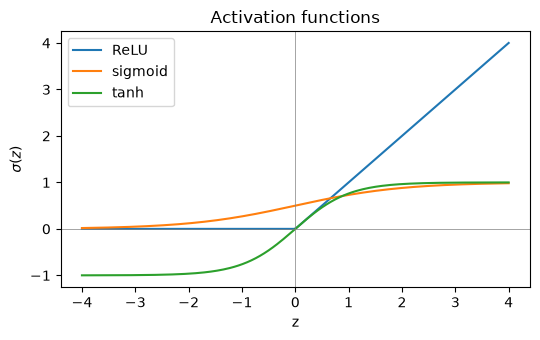

In [7]:
z = torch.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(z, torch.relu(z), label="ReLU")
ax.plot(z, torch.sigmoid(z), label="sigmoid")
ax.plot(z, torch.tanh(z), label="tanh")
ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("z"); ax.set_ylabel(r"$\sigma(z)$"); ax.legend()
ax.set_title("Activation functions")
fig.tight_layout(); fig.savefig(FIGDIR / "activation_functions.png", dpi=200)
plt.show()


> **Common errors — Section 2**
> - `layer.weight` has shape `(F, D)` — **out features first** — so the
>   manual formula needs `x @ layer.weight.T`, not `x @ layer.weight`.
> - Forgetting `torch.no_grad()` when overwriting parameters in place (as in
>   `combined.weight.copy_(...)`) can interfere with autograd bookkeeping.
> - Believing *any* two-layer network without activation is "deep" — by the
>   algebra above it collapses to one affine map, regardless of the hidden
>   width $F$.


### ✅ Check yourself — Section 2

Prints `Section 2 OK`. The manual matmul matches `nn.Linear` exactly; the collapsed single-layer network matches the two-layer, no-activation network to numerical precision.


In [8]:
# --- checkpoint (do not edit) ---
assert torch.allclose(h_builtin, h_manual, atol=1e-6)
assert (out_stacked - out_combined).abs().max().item() < 1e-4
assert (FIGDIR / "activation_functions.png").is_file()
print("Section 2 OK")


Section 2 OK


**Conceptual questions**


1. If you inserted `torch.relu` between `layer1` and `layer2` above, would the
   collapse-to-one-layer argument still work? Why or why not?
2. Why does making the hidden layer *wider* (`nn.Linear(7, 500)` instead of
   `nn.Linear(7, 5)`) not fix the collapse problem on its own?


**Answers**


1. No — `torch.relu` is non-linear, so
   $W_2\,\text{ReLU}(W_1\vec x+\vec b_1)+\vec b_2$ cannot in general be
   rewritten as $(W_2W_1)\vec x + \text{const}$; the algebraic collapse relied
   entirely on both maps being linear.
2. Matrix composition is linear regardless of the intermediate dimension —
   $(W_2W_1)$ is still just some $1\times 7$ matrix no matter how large the
   hidden width $F$ was; width without non-linearity still only ever expresses
   linear functions of $\vec x$.


---
## 3. Backpropagation: chain rule vs `autograd`

For a one-feature linear model $\hat y = wx+b$ with MSE loss
$L=\frac1N\sum_i(y_i-\hat y_i)^2$ (Week 03, Section 1), calculus gives the
gradients directly:

$$\frac{\partial L}{\partial w} = -\frac{2}{N}\sum_i x_i(y_i-\hat y_i), \qquad
  \frac{\partial L}{\partial b} = -\frac{2}{N}\sum_i (y_i-\hat y_i).$$

**Backpropagation is exactly the chain rule**, applied automatically to
arbitrarily long chains of operations. PyTorch tracks every operation on a
tensor with `requires_grad=True`, and `loss.backward()` fills in
`.grad` for every such tensor. We check both routes agree on the *same* data.

**What to look for:** the hand-computed gradient and `autograd`'s gradient
match to several decimal places.


In [9]:
x_single = Xtr[:, desc_names.index("MolLogP")]     # (893,)
y_single = ytr.squeeze(-1)                          # (893,)

w0, b0 = 0.3, -1.0    # an arbitrary point to evaluate the gradient at

# --- hand-derived gradient (plain tensors, no autograd) ---
pred = w0 * x_single + b0
error = y_single - pred
grad_w_manual = (-2.0 / len(x_single) * (x_single * error)).sum().item()
grad_b_manual = (-2.0 / len(x_single) * error).sum().item()

# --- autograd: same computation, but w and b track gradients ---
w = torch.tensor(w0, requires_grad=True)
b = torch.tensor(b0, requires_grad=True)
loss = ((y_single - (w * x_single + b)) ** 2).mean()
loss.backward()                       # fills in w.grad, b.grad via the chain rule

print(f"grad_w:  manual {grad_w_manual:.6f}   autograd {w.grad.item():.6f}")
print(f"grad_b:  manual {grad_b_manual:.6f}   autograd {b.grad.item():.6f}")


grad_w:  manual 4.104936   autograd 4.104936
grad_b:  manual 4.125951   autograd 4.125951


> **Common errors — Section 3**
> - Calling `.backward()` twice without clearing gradients — PyTorch
>   **accumulates** gradients into `.grad` by default; a real training loop
>   must call `optimizer.zero_grad()` every step (Section 4).
> - Building `w`/`b` from a tensor that already requires grad *inside* a
>   `with torch.no_grad()` block — the graph will not be tracked and
>   `.backward()` raises.
> - Off-by-factor-of-2 errors are the most common hand-derivation mistake —
>   this is exactly why comparing against `autograd` is good practice.


### ✅ Check yourself — Section 3

Prints `Section 3 OK`. Manual and autograd gradients agree to four decimal places.


In [10]:
# --- checkpoint (do not edit) ---
assert abs(grad_w_manual - w.grad.item()) < 1e-4
assert abs(grad_b_manual - b.grad.item()) < 1e-4
print("Section 3 OK")


Section 3 OK


**Conceptual questions**


1. Why does `loss.backward()` need no argument here, but would need one
   (`loss.backward(gradient=...)`) if `loss` were not a scalar?
2. In a real training loop, why call `optimizer.zero_grad()` *before*
   `loss.backward()` rather than after?


**Answers**


1. Backprop computes $\partial(\text{scalar})/\partial(\text{everything})$;
   for a non-scalar output PyTorch cannot infer "the" gradient direction
   without you supplying the upstream gradient (e.g. from a further loss),
   which is what the `gradient=` argument provides.
2. Gradients accumulate in `.grad` across every call to `.backward()`;
   zeroing beforehand (or immediately after the previous `optimizer.step()`)
   ensures each step's update reflects only the *current* batch's gradient,
   not a running sum from previous steps.


---
## 4. Building an MLP; one manual training step

An **MLP** (multilayer perceptron) stacks dense layers with activations
between them. We define one as an `nn.Module`: `__init__` declares the
layers, `forward` describes how data flows through them.

We then perform **one** training step by hand — the same four lines every
PyTorch training loop repeats: zero the gradients, compute the loss, back­
propagate, step the optimiser. Week 05B wraps this in a loop over many epochs
with proper train/val/test bookkeeping; here we just confirm it runs and the
loss moves in the right direction.

**What to look for:** the model has $7\times32+32 + 32\times32+32 + 32\times1+1
= 1345$ trainable parameters; loss after one optimiser step is lower than
before it.


In [11]:
class MLP(nn.Module):
    """Two hidden ReLU layers, one linear output -- a regression MLP."""

    def __init__(self, in_dim=7, hidden=32):
        super().__init__()
        self.layer1 = nn.Linear(in_dim, hidden)
        self.layer2 = nn.Linear(hidden, hidden)
        self.layer3 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)          # no activation: regression output

torch.manual_seed(SEED)
model = MLP(in_dim=7, hidden=32)
n_params = sum(p.numel() for p in model.parameters())
print("trainable parameters:", n_params)

optimiser = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

batch_x, batch_y = Xtr[:64], ytr[:64]           # one small batch
loss_before = loss_fn(model(batch_x), batch_y).item()

optimiser.zero_grad()                            # 1. clear old gradients
loss = loss_fn(model(batch_x), batch_y)          # 2. forward pass + loss
loss.backward()                                  # 3. backpropagate
optimiser.step()                                  # 4. update parameters

loss_after = loss_fn(model(batch_x), batch_y).item()
print(f"loss before step: {loss_before:.4f}   after step: {loss_after:.4f}")


trainable parameters: 1345
loss before step: 15.8787   after step: 14.7944


> **Common errors — Section 4**
> - Forgetting `super().__init__()` in a custom `nn.Module` — parameters
>   silently fail to register, and `model.parameters()` is empty.
> - Calling `model(x)` when `x` has the wrong last-axis size (must be 7 here,
>   matching `in_dim`) — raises a matrix-multiply shape error identical in
>   spirit to Section 1's broadcasting errors.
> - Evaluating `loss_after` on a **different** batch than `loss_before` and
>   concluding the model "got worse" — always compare on the same data when
>   checking one step's effect.


### ✅ Check yourself — Section 4

Prints `Section 4 OK`. Parameter count is exactly 1345; loss after the single optimiser step is lower than before it.


In [12]:
# --- checkpoint (do not edit) ---
assert n_params == 7 * 32 + 32 + 32 * 32 + 32 + 32 * 1 + 1
assert loss_after < loss_before
assert all(p.grad is not None for p in model.parameters())
print("Section 4 OK")


Section 4 OK


**Conceptual questions**


1. One step lowered the loss on `batch_x`/`batch_y`. Does that guarantee the
   loss on a *held-out* batch also fell? Why is this exactly Week 03's
   train/test distinction again?
2. Why does `p.grad is not None` hold for every parameter only *after*
   `loss.backward()`, not right after the model is constructed?


**Answers**


1. No — one gradient step only guarantees improvement on the exact data it
   was computed from; whether it generalises to unseen data is precisely the
   train-vs-test question from Week 03, now playing out one optimiser step at
   a time instead of one whole model at a time.
2. Freshly constructed parameters have `grad = None` because no backward pass
   has run yet; `.grad` is populated only when `.backward()` traces the
   computation graph back through each parameter that was actually used to
   compute the loss.


---
## 5. Exercises


### Exercise 1 — standardise with broadcasting *(easy, ~12 min)*

Write `standardize(X)` that returns `(X - mean) / std` computed along
`dim=0`, using PyTorch broadcasting (no loop). Apply it to `Xtr` and confirm
it matches Section 1's `Xtr_std`.

<details><summary>Show hint</summary>

`X.mean(dim=0)` and `X.std(dim=0)` both have shape `(D,)`, which broadcasts
against `X`'s shape `(N, D)` exactly like Section 1.
</details>


In [13]:
def standardize(X):
    """(X - mean) / std along dim=0, via broadcasting."""
    return (X - X.mean(dim=0)) / X.std(dim=0)

Xtr_std_check = standardize(Xtr)
print(torch.allclose(Xtr_std_check, Xtr_std, atol=1e-5))


True


In [14]:
# --- check your answer (do not edit) ---
assert torch.allclose(Xtr_std_check, Xtr_std, atol=1e-5)
toy = torch.tensor([[1.0, 10.0], [2.0, 20.0], [3.0, 30.0]])
toy_std = standardize(toy)
assert toy_std.mean(dim=0).abs().max().item() < 1e-6
print("Exercise 1 OK")


Exercise 1 OK


### Exercise 2 — count parameters without building the model *(medium, ~12 min)*

Write `count_parameters(in_dim, hidden_sizes, out_dim)` returning the number
of trainable parameters an MLP with those layer sizes would have (each
`nn.Linear(a, b)` contributes $ab+b$ parameters), **without** constructing any
`nn.Module`. Check it against `MLP(7, 32)`'s actual count from Section 4.

<details><summary>Show hint</summary>

Build the full list of consecutive layer sizes
`[in_dim, *hidden_sizes, *hidden_sizes[1:]... ]` — for this MLP it is simply
`[in_dim, hidden, hidden, out_dim]`; sum `a*b+b` over consecutive pairs.
</details>


In [15]:
def count_parameters(in_dim, hidden_sizes, out_dim):
    """#parameters of an MLP: in_dim -> hidden_sizes... -> out_dim, all Linear."""
    sizes = [in_dim, *hidden_sizes, out_dim]
    total = 0
    for a, b in zip(sizes[:-1], sizes[1:]):
        total += a * b + b
    return total

predicted = count_parameters(7, [32, 32], 1)
print("predicted:", predicted, " actual:", n_params)


predicted: 1345  actual: 1345


In [16]:
# --- check your answer (do not edit) ---
assert predicted == n_params == 1345
assert count_parameters(7, [], 1) == 7 * 1 + 1     # a single linear layer
print("Exercise 2 OK")


Exercise 2 OK


### Exercise 3 — gradient of ridge-penalised loss *(medium, ~18 min)*

Extend Section 3: for $L=\frac1N\sum_i(y_i-(wx_i+b))^2+\lambda w^2$ (an L2
penalty, Week 03), derive
$\partial L/\partial w=(\text{plain gradient}) + 2\lambda w$ and write
`manual_grad_ridge(x, y, w, b, lam)` returning `(grad_w, grad_b)`. Confirm
against `autograd` at `w=0.3, b=-1.0, lam=0.5`.

<details><summary>Show hint</summary>

Reuse Section 3's plain-gradient computation for `grad_w`/`grad_b`, then add
`2*lam*w` to `grad_w` only (the penalty does not involve `b`).
</details>


In [17]:
def manual_grad_ridge(x, y, w, b, lam):
    """(grad_w, grad_b) of mean-squared-error + lam*w**2, by hand."""
    pred = w * x + b
    error = y - pred
    grad_w = (-2.0 / len(x) * (x * error)).sum().item() + 2 * lam * w
    grad_b = (-2.0 / len(x) * error).sum().item()
    return grad_w, grad_b

gw_manual, gb_manual = manual_grad_ridge(x_single, y_single, 0.3, -1.0, 0.5)

w2 = torch.tensor(0.3, requires_grad=True)
b2 = torch.tensor(-1.0, requires_grad=True)
loss2 = ((y_single - (w2 * x_single + b2)) ** 2).mean() + 0.5 * w2 ** 2
loss2.backward()
print("manual:", gw_manual, gb_manual, " autograd:", w2.grad.item(), b2.grad.item())


manual: 4.404935646057129 4.125950813293457  autograd: 4.404935836791992 4.125950813293457


In [18]:
# --- check your answer (do not edit) ---
w2 = torch.tensor(0.3, requires_grad=True)
b2 = torch.tensor(-1.0, requires_grad=True)
loss2 = ((y_single - (w2 * x_single + b2)) ** 2).mean() + 0.5 * w2 ** 2
loss2.backward()
assert abs(gw_manual - w2.grad.item()) < 1e-4
assert abs(gb_manual - b2.grad.item()) < 1e-4
assert abs(gb_manual - grad_b_manual) < 1e-9   # penalty does not touch grad_b
print("Exercise 3 OK")


Exercise 3 OK


### Exercise 4 — verify the linear-collapse for a *deeper* stack *(harder, ~20 min)*

Section 2 collapsed **two** no-activation layers into one. Write
`collapse_linear_stack(layers)` that takes a list of `nn.Linear` modules (all
without activations between them) and returns a single `nn.Linear` with the
combined effect, for **any** number of layers (not just two).

<details><summary>Show hint</summary>

Fold left to right: start with `W = layers[0].weight`, `b = layers[0].bias`;
for each subsequent layer, `W = layer.weight @ W`,
`b = layer.weight @ b + layer.bias`.
</details>


In [19]:
def collapse_linear_stack(layers):
    """Combine a list of no-activation nn.Linear layers into one nn.Linear."""
    W, b = layers[0].weight, layers[0].bias
    for layer in layers[1:]:
        W = layer.weight @ W
        b = layer.weight @ b + layer.bias
    combined_layer = nn.Linear(layers[0].in_features, layers[-1].out_features)
    with torch.no_grad():
        combined_layer.weight.copy_(W)
        combined_layer.bias.copy_(b)
    return combined_layer

stack = [nn.Linear(7, 5), nn.Linear(5, 6), nn.Linear(6, 3)]
x_test = Xtr[:10]
out_seq = stack[2](stack[1](stack[0](x_test)))
out_collapsed = collapse_linear_stack(stack)(x_test)
print("max abs diff:", (out_seq - out_collapsed).abs().max().item())


max abs diff: 5.960464477539063e-08


In [20]:
# --- check your answer (do not edit) ---
assert (out_seq - out_collapsed).abs().max().item() < 1e-4
combined = collapse_linear_stack(stack)
assert combined.in_features == 7 and combined.out_features == 3
print("Exercise 4 OK")


Exercise 4 OK


---
## Summary — what you learned

- **Tensors**: rank, shape, the batch-axis convention, and broadcasting —
  the same rules whether you are standardising features or building a
  pairwise distance matrix.
- **Dense layers** ($\sigma(Wx+b)$) and the algebraic proof that stacking
  linear layers **without** non-linearity collapses to one linear layer.
- **Backpropagation** is the chain rule, applied automatically; you checked it
  by hand against `autograd` twice (plain MSE, then with an L2 penalty).
- Defined an **MLP** as an `nn.Module` and ran the four-line anatomy of a
  training step: `zero_grad` → forward → `backward` → `step`.

Week 05B wraps this into a full training loop with a proper train/val/test
split, loss curves, early stopping and a small hyperparameter sweep.


## Further reading (course source list only)

- dmol.pub *Tensors and shapes*: <https://dmol.pub/math/tensors-and-shapes.html>
- dmol.pub *Deep learning overview*: <https://dmol.pub/dl/introduction.html>
- dmol.pub *Standard layers*: <https://dmol.pub/dl/layers.html>
- Colab alternative (EPFL *AI for Chemistry*, intro to deep learning):
  <https://colab.research.google.com/github/schwallergroup/ai4chem_course/blob/main/notebooks/03%20-%20Intro%20to%20Deep%20Learning/01_intro_to_dl.ipynb>


## Attribution

Original teaching material for *AI for Chemistry*, adapted and rewritten from:

- **dmol.pub** (A. White) — the tensor/shape/broadcasting framing, the dense
  layer equation and the non-linearity argument, and the loss/optimiser/
  training-step pattern. CC-BY 4.0. <https://dmol.pub>
- **EPFL CH-457 *AI for Chemistry*** (Schwaller group) — the choice to teach
  PyTorch mechanics on the course's own ESOL solubility data. MIT licence.
  <https://github.com/schwallergroup/ai4chem_course>

Continues the ESOL dataset and 7-descriptor block from Weeks 02-03. No
verbatim text is reproduced from the sources above.
